<a href="https://colab.research.google.com/github/Kaveh-Ramezani/202610ELC536501/blob/main/3/FuncAppr_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensorflow V1 + ReLU + Saddle Function Model

### 0.  The first imports

In [90]:
# %tensorflow_version 1.x
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

### 1. The 2D function to be modeled

In [91]:
#The 2D function that is to be modeled
def F_mv(x1,x2):
    # return np.sin(np.pi*x1/2.0)*np.cos(np.pi*x2/4.0) # Sinusoidal function
    # return np.exp(-x1**2-x2**2) # Gaussian Mixture Model (GMM)
    return x1**2 - x2**2 # Saddle function

### 2. Activation Functions

In [92]:
def Sigmoid(x):
    return 1/(1 + np.exp(-x))
def ReLU(x):
    return np.maximum(0,x)
def Tanh(x):
    return np.tanh(x)
def ELU(x):
    return np.where(x>0,x,np.exp(x)-1)

ActivationFunction = ReLU

### 3. Visualization of the target function, functions



In [93]:
def visualize_original(Width,Height,U,V):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            H2[j,i] = F_mv(u,v)  #The 2D func

    return H2

### 4. Visualize combined functions

In [94]:
def visualize_2layer(Width,Height,U,V,W1,b1,W2,b2):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            x = [u,v]
            h1 = np.vectorize(ActivationFunction)(x*W1+b1)
            h2 = h1 * W2 + b2
            H2[j,i] = h2[0,0]

    return H2

### 5. Generating Training Data

In [95]:
#Generate training data
A = 2
nb_samples = 1000
F = F_mv
X_train = np.random.uniform(-A,A,(nb_samples,2))

Y_train = np.zeros(shape=(nb_samples,1))

for i in range(nb_samples):
    Y_train[i] = [F(X_train[i][0],X_train[i][1])]


### 6. Making the nural network

In [96]:
#Two-Layer Neural Network Structure
N1 = 20  #Number of neurons in the hidden layer

tf.reset_default_graph()
session = tf.InteractiveSession()
# The input layer
with tf.variable_scope("Input"):
    # The input layer with two inputs
    x = tf.placeholder(tf.float32,shape=[None,2])
# The Hidden Layer
with tf.variable_scope("HiddenLayer"):
    # For each neuron we have:
    #   1. Two inputs (From input layer), and
    #   2. N1 outputs (to hidden layer)
    # Each weight
    W1 = tf.Variable(tf.truncated_normal([2,N1],stddev=np.sqrt(6/(2+N1))))
    b1 = tf.Variable(tf.zeros([N1]))
    h1 = tf.nn.relu(tf.add(tf.matmul(x,W1),b1))
# The Output Layer
with tf.variable_scope("OutputLayer"):
    # For each neuron we have:
    #   1. Two inputs (From the Hidden Layer), and
    #   2. N1 outputs (to the output)
    # Each weight
    W2 = tf.Variable(tf.truncated_normal([N1,1],stddev=np.sqrt(6/(N1+1))))
    b2 = tf.Variable(tf.zeros([1]))
    h2 = tf.add(tf.matmul(h1,W2),b2)

with tf.variable_scope("Output"):
    y = tf.placeholder(tf.float32,[None,1])

with tf.variable_scope("Loss"):
    Loss = tf.reduce_sum(tf.square(h2 - y))

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


### 7. Optimization

In [97]:
#Optimization
eta =(1e-3)
optimizer = tf.train.GradientDescentOptimizer(eta)
optimizer_one_step = optimizer.minimize(Loss)
session.run(tf.global_variables_initializer())

# File_Writer = tf.summary.FileWriter('.\\TwoLayergraph',session.graph)

epochs = int(1e5)
batch_size = 100
epochs_between_two_evaluations = int(epochs/10)
loss_history = []

for i in range(epochs):
    idx = np.random.permutation(X_train.shape[0])[:batch_size]
    feed_dict = {x:X_train[idx],y:Y_train[idx]}
    optimizer_one_step.run(feed_dict=feed_dict)
    
    loss_history.append(session.run(Loss,feed_dict=feed_dict))

    if (i+1) % epochs_between_two_evaluations == 0:
        [curr_loss] = session.run([Loss],{x:X_train,y:Y_train})
        print(f'epoch: {i+1}, loss: {curr_loss:.4f}')

epoch: 10000, loss: 2.2001
epoch: 20000, loss: 2.3600
epoch: 30000, loss: 2.0242
epoch: 40000, loss: 2.0154
epoch: 50000, loss: 1.8455
epoch: 60000, loss: 1.8287
epoch: 70000, loss: 1.8199
epoch: 80000, loss: 1.8533
epoch: 90000, loss: 1.8828
epoch: 100000, loss: 1.8207


### 8. Visualize Training Progress

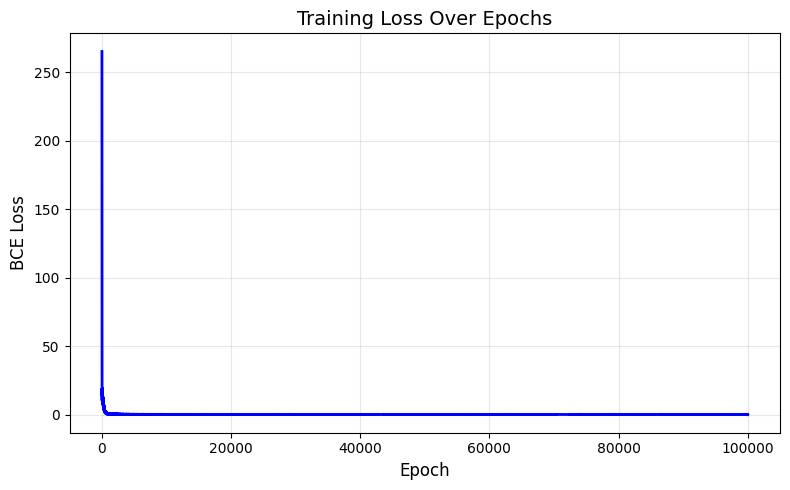

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_history, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Visualization

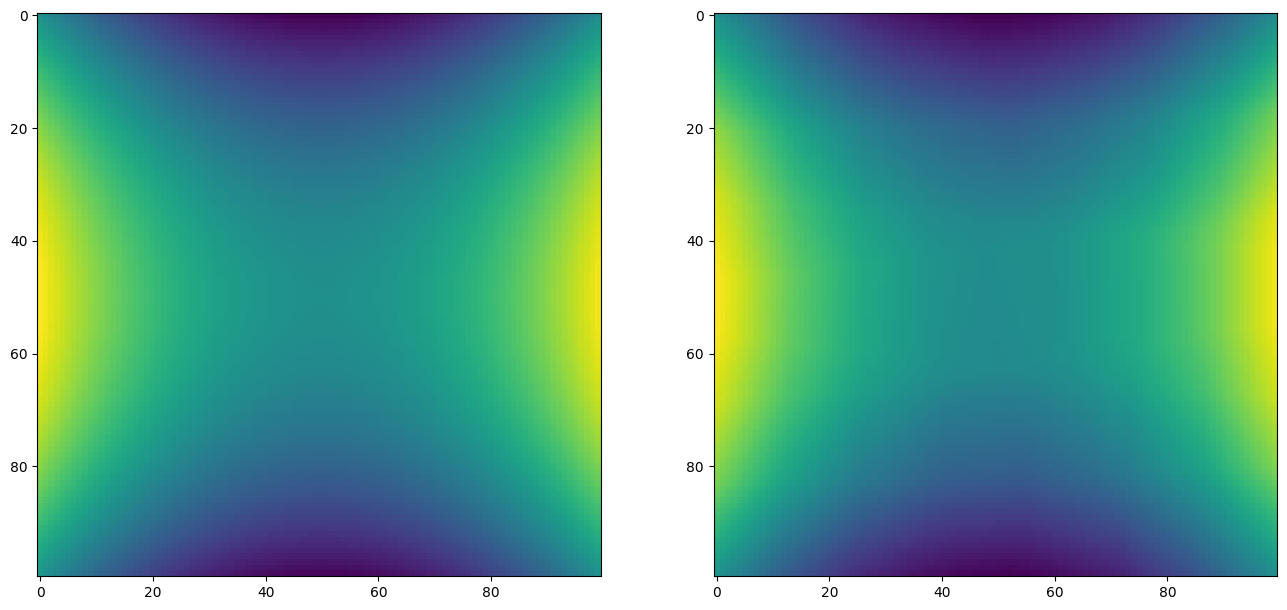

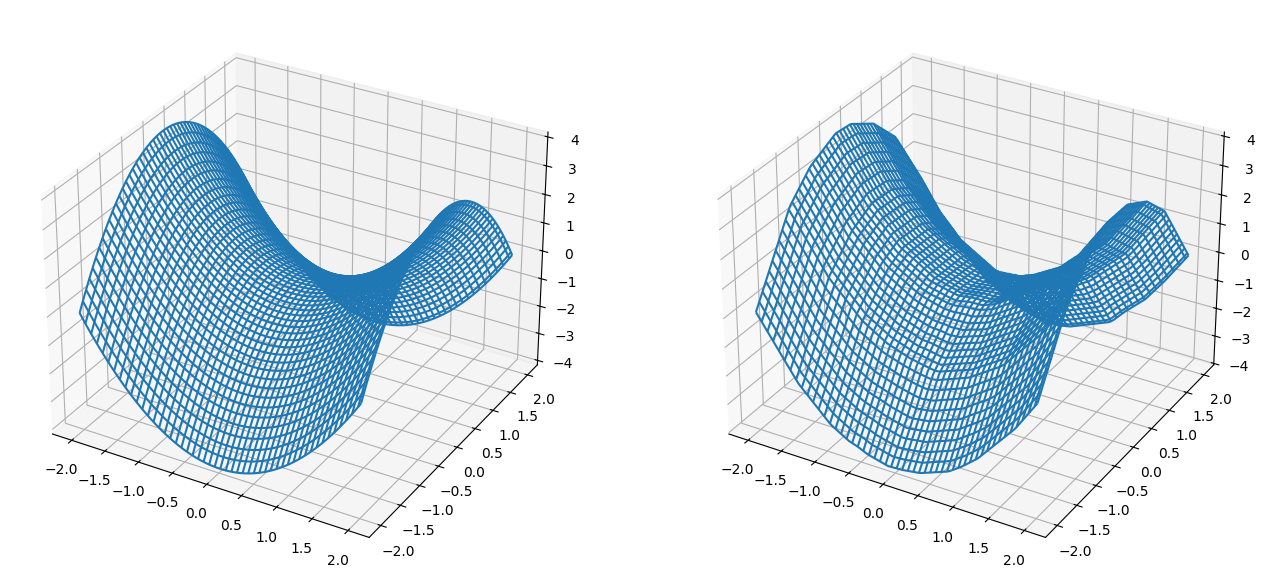

In [99]:
#Visualize the predicted function
[curr_W1,curr_b1,curr_W2,curr_b2,curr_loss] = session.run([W1,b1,W2,b2,Loss],{x:X_train,y:Y_train})

curr_W1 = np.asmatrix(curr_W1)
curr_W2 = np.asmatrix(curr_W2)

I_original = visualize_original(100,100,A,A)

I = visualize_2layer(100,100,A,A,curr_W1,curr_b1,curr_W2,curr_b2)

f = plt.figure(figsize=(16, 8))

f.add_subplot(1,2, 1)
plt.imshow(I_original)
f.add_subplot(1,2, 2)
plt.imshow(I)
#plt.show(block=True)

x = np.linspace(-A, A, 100)
y = np.linspace(-A, A, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121,projection='3d')
ax1.plot_wireframe(X, Y, I_original)
ax2 = fig.add_subplot(122,projection='3d')
ax2.plot_wireframe(X, Y, I)

session.close()